# Rekurencyjne Sieci Neuronowe (RNN)

Rekurencyjne Sieci Neuronowe (Recurrent Neural Networks, **RNN**) są specjalnym rodzajem sztucznych sieci neuronowych zaprojektowanych do przetwarzania **danych sekwencyjnych**, czyli takich, w których **kolejność obserwacji ma znaczenie**.

W przeciwieństwie do klasycznych modeli uczenia maszynowego, które traktują każdą próbkę danych niezależnie, RNN potrafią wykorzystywać informacje z **poprzednich kroków czasowych** podczas przetwarzania aktualnego wejścia.

Najważniejszą cechą RNN jest obecność **wewnętrznego stanu (hidden state)**, który pełni rolę pamięci sieci. Stan ten jest aktualizowany w każdym kroku przetwarzania sekwencji i przechowuje informację o wcześniejszych elementach danych.

Dzięki temu RNN potrafią modelować **zależności czasowe** oraz **kontekst w sekwencjach danych**.

Typowe zastosowania RNN obejmują:

- analizę **szeregów czasowych**
- **przetwarzanie języka naturalnego (NLP)**
- **rozpoznawanie mowy**
- **generowanie tekstu**
- analizę **sygnałów audio**

---

# 2. Różnice między RNN a sieciami Feed-Forward

## Feed-Forward Neural Network (FFNN)

Klasyczne sieci neuronowe typu **Feed-Forward** są najprostszą architekturą sieci neuronowych.

- Informacja przepływa **w jednym kierunku** — od warstwy wejściowej, przez warstwy ukryte, do warstwy wyjściowej.
- Sieć **nie posiada mechanizmu pamięci**, dlatego każda próbka danych jest analizowana niezależnie.
- Kolejność danych wejściowych **nie wpływa na wynik modelu**.

---

## Recurrent Neural Network (RNN)

Rekurencyjne sieci neuronowe rozszerzają architekturę sieci neuronowych o **połączenia rekurencyjne**, które pozwalają przekazywać informacje pomiędzy kolejnymi krokami przetwarzania sekwencji.

Charakterystyka:

- Komórki sieci posiadają **stan ukryty (hidden state)** przechowujący informację o wcześniejszych elementach sekwencji.
- Dane przetwarzane są **krok po kroku w czasie**.
- Wynik modelu zależy zarówno od **aktualnego wejścia**, jak i od **poprzednich stanów sieci**.
- Architektura umożliwia modelowanie **zależności czasowych** w danych.


---

**Podsumowanie**

- Sieć **Feed-Forward** analizuje dane tak, jak kalkulator — każda obserwacja jest przetwarzana niezależnie.
- Sieć **RNN** działa bardziej jak czytelnik tekstu — rozumie bieżący element sekwencji w kontekście wcześniejszych elementów.

---

`źródło`: Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning.** MIT Press. Chapter 10: Sequence Modeling: Recurrent and Recursive Nets.

https://www.deeplearningbook.org
Przykładowa architektura sieci RNN

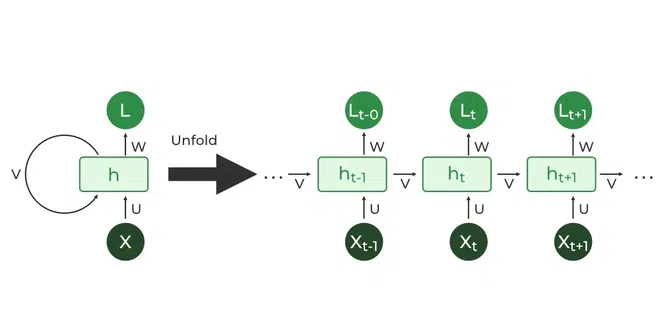

(źródło: https://www.geeksforgeeks.org/introduction-to-recurrent-neural-network/)

### Przykład regresji z użyciem RNN

Przewidywanie miesięcznej ilości pasażerów.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# Ładowanie danych
data = pd.read_csv("https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv", parse_dates=["Month"], index_col="Month")
data = data.dropna()
data.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [3]:
# Konwersja do numpy
data = data.values

## Skalowanie zmiennej target
---

**Uwaga**

Zastosowanie **MinMaxScaling** często poprawia stabilność i skuteczność treningu sieci neuronowych. Wynika to z faktu, że wiele algorytmów optymalizacji (np. gradient descent oraz jego warianty) działa efektywniej, gdy dane wejściowe i wyjściowe znajdują się w podobnych zakresach wartości.

Dodatkowo skalowanie może ułatwić interpretację wartości niektórych metryk błędu podczas treningu modelu.

Należy jednak pamiętać, że predykcje modelu są wówczas generowane w **przeskalowanej przestrzeni**. Aby porównać je z danymi w oryginalnej skali, konieczne jest wykonanie operacji odwrotnego skalowania przy użyciu metody `inverse_transform`.

---

### Przykład użycia `MinMaxScaler`

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(<FIT_DATA>)
```

In [4]:
# Podział na dane treningowe i testowe (ostatnie dane w czasie są brane jako dane testowe)
train_size = int(data.shape[0] * 0.8)
test_size = data.shape[0] - train_size
train, test = data[0:train_size,:], data[train_size:len(data),:]
print(len(train), len(test))

115 29


In [5]:
def create_data(data, seq_length=5, horizon=1):
    X, y = [], []
    for i in range(len(data) - seq_length - horizon):
        X.append(data[i:(i + seq_length), 0])
        y.append(data[i + seq_length + horizon - 1, 0])
    return np.array(X), np.array(y)

In [6]:
# Tworzenie datasetu
seq_length = 5
X_train, y_train = create_data(train, seq_length)
X_test, y_test = create_data(test, seq_length)

In [7]:
# Nadanie danym odpowiedniego kształtu do sieci neuronowej
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [8]:
X_train_fnn = X_train.reshape(X_train.shape[0], -1)
X_test_fnn = X_test.reshape(X_test.shape[0], -1)

In [9]:
X_train_fnn.shape

(109, 5)

In [10]:
X_train.shape

(109, 5, 1)

In [11]:
X_test[:2]

array([[[505],
        [404],
        [359],
        [310],
        [337]],

       [[404],
        [359],
        [310],
        [337],
        [360]]])

In [12]:
y_test[:10]

array([360, 342, 406, 396, 420, 472, 548, 559, 463, 407])

In [60]:
# Definicja Sieci FNN
fnn_model = Sequential([
    Dense(64, activation='relu', input_shape=(seq_length,)),
    Dense(32, activation='relu'),
    Dense(1)
])
fnn_model.compile(optimizer='adam', loss='mae')

In [61]:
# Przykładowy trening modelu FNN, może być usprawniony
fnn_model.fit(X_train_fnn, y_train, epochs=10, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 91.2108 - val_loss: 69.4189
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 33.9688 - val_loss: 67.5830
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 30.1272 - val_loss: 63.8448
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 27.8433 - val_loss: 61.9371
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 27.0439 - val_loss: 59.6494
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 26.0238 - val_loss: 58.2374
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25.5292 - val_loss: 62.0144
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 30.4946 - val_loss: 55.9654
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 26.7069 - val_loss: 60.7606
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 24.4181 - val_loss: 53.3159


In [109]:
# Defninicja Sieci RNN
rnn_model = Sequential([
    SimpleRNN(50, activation='relu', return_sequences=False, input_shape=(seq_length, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mae')

In [110]:
# Przykładowy trening modelu RNN, może być usprawniony
rnn_model.fit(X_train, y_train, epochs=30, batch_size=8, validation_data=(X_test, y_test))

Epoch 1/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 151.9851 - val_loss: 102.4276
Epoch 2/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37.7646 - val_loss: 74.9976
Epoch 3/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 34.8615 - val_loss: 74.9340
Epoch 4/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35.7056 - val_loss: 72.0338
Epoch 5/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 32.8318 - val_loss: 70.0850
Epoch 6/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.4349 - val_loss: 69.2900
Epoch 7/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30.6391 - val_loss: 74.1531
Epoch 8/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 31.1102 - val_loss: 69.2131
Epoch 9/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30.1690 - val_loss: 82.6289
Epoch 10/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 30.0631 - val_loss: 64.1866
Epoch 11/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28.9881 - val_loss: 63.7054
Epoch 12/30
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/ste

In [111]:
#  Predykcje
y_pred_fnn = fnn_model.predict(X_test_fnn).flatten()
y_pred_rnn = rnn_model.predict(X_test).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


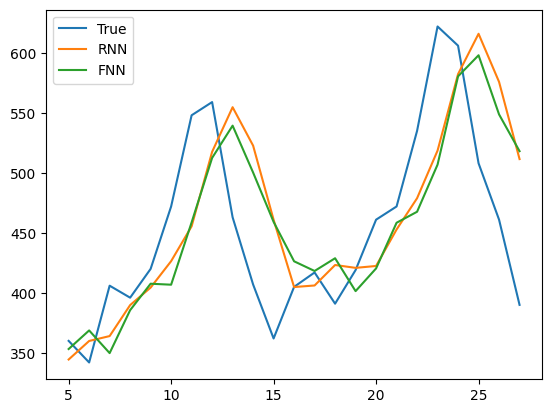

In [112]:
plt.plot(
    range(seq_length, seq_length + len(y_test)),
    y_test,
    label="True"
)


plt.plot(
    range(seq_length, seq_length + len(y_pred_rnn)),
    y_pred_rnn,
    label="RNN"
)

plt.plot(
    range(seq_length, seq_length + len(y_pred_fnn)),
    y_pred_fnn,
    label="FNN"
)

plt.legend()
plt.show()

## Analiza wpływu kolejności i ostatniego punktu na predykcje FNN i RNN

Bierzemy jedną sekwencję testową i przeprowadzamy trzy eksperymenty:

1. **Odwrócenie kolejności danych (reversed)**  
   Sprawdzamy, czy zmiana kolejności całej sekwencji wpływa na predykcję.
   - FNN przetwarza dane jako wektor → kolejność teoretycznie nie powinna mieć znaczenia.
   - RNN przetwarza dane krok po kroku → kolejność jest kluczowa.

2. **Modyfikacja ostatniego punktu (last value sensitivity)**  
   Zwiększamy ostatnią wartość sekwencji o 100, aby sprawdzić, na ile predykcja zależy od ostatniego elementu.

3. **Losowa permutacja (shuffle)**  
   Sprawdzamy wpływ całkowicie losowej kolejności na predykcje modeli.

**Interpretacja wyników:**  
- Jeśli zmiana kolejności znacząco zmienia predykcję → model rozumie kolejność danych.  
- Jeśli wrażliwość na ostatni punkt jest wysoka → model silnie zależy od końcówki sekwencji.  

In [19]:
idx = 2
sample = X_test[idx].copy()
true_value = y_test[idx]

print("=== SAMPLE ===")
print("Original:", sample.flatten())
print("True value:", true_value)

# =========================
# Test 1: odwrócenie danych
# =========================
reversed_seq = sample[::-1]

fnn_orig = fnn_model.predict(sample.reshape(1, -1), verbose=0)
fnn_rev  = fnn_model.predict(reversed_seq.reshape(1, -1), verbose=0)

rnn_orig = rnn_model.predict(sample.reshape(1, seq_length, 1), verbose=0)
rnn_rev  = rnn_model.predict(reversed_seq.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 1: ODWRÓCENIE DANYCH ===")
print("FNN original :", fnn_orig[0][0])
print("FNN reversed :", fnn_rev[0][0])
print("FNN diff     :", abs(fnn_orig - fnn_rev)[0][0])

print("RNN original :", rnn_orig[0][0])
print("RNN reversed :", rnn_rev[0][0])
print("RNN diff     :", abs(rnn_orig - rnn_rev)[0][0])

# =========================
# TEST 2: WRAŻLIWOŚĆ NA OSTATNI PUNKT DANYCH
# =========================
modified = sample.copy()
modified[-1] += 100  # zmieniamy tylko ostatni punkt

fnn_mod = fnn_model.predict(modified.reshape(1, -1), verbose=0)
rnn_mod = rnn_model.predict(modified.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 2: WRAŻLIWOŚĆ NA OSTATNI PUNKT DANYCH")
print("FNN sensitivity:", abs(fnn_orig - fnn_mod)[0][0])
print("RNN sensitivity:", abs(rnn_orig - rnn_mod)[0][0])

# =========================
# TEST 3: SHUFFLE
# =========================
shuffled = np.random.permutation(sample)

fnn_shuf = fnn_model.predict(shuffled.reshape(1, -1), verbose=0)
rnn_shuf = rnn_model.predict(shuffled.reshape(1, seq_length, 1), verbose=0)

print("\n=== TEST 3: SHUFFLE ===")
print("FNN shuffled :", fnn_shuf[0][0])
print("RNN shuffled :", rnn_shuf[0][0])

print("\n=== INTERPRETACJA ===")

fnn_diff_rev = abs(fnn_orig - fnn_rev)[0][0]
rnn_diff_rev = abs(rnn_orig - rnn_rev)[0][0]

fnn_last = abs(fnn_orig - fnn_mod)[0][0]
rnn_last = abs(rnn_orig - rnn_mod)[0][0]

print(f"Reverse sensitivity → FNN: {fnn_diff_rev:.2f}, RNN: {rnn_diff_rev:.2f}")
print(f"Last value sensitivity → FNN: {fnn_last:.2f}, RNN: {rnn_last:.2f}")


=== SAMPLE ===
Original: [359 310 337 360 342]
True value: 406

=== TEST 1: ODWRÓCENIE DANYCH ===
FNN original : 352.85855
FNN reversed : 361.1413
FNN diff     : 8.282745
RNN original : 365.2865
RNN reversed : 351.52054
RNN diff     : 13.765961

=== TEST 2: WRAŻLIWOŚĆ NA OSTATNI PUNKT DANYCH
FNN sensitivity: 51.72296
RNN sensitivity: 17.163239

=== TEST 3: SHUFFLE ===
FNN shuffled : 355.4975
RNN shuffled : 363.33484

=== INTERPRETACJA ===
Reverse sensitivity → FNN: 8.28, RNN: 13.77
Last value sensitivity → FNN: 51.72, RNN: 17.16


# Zadanie 1 – Prognozowanie szeregu czasowego

Szereg czasowy to uporządkowana w czasie sekwencja obserwacji. W wielu zadaniach analizy danych interesuje nas **prognozowanie przyszłych wartości na podstawie wartości historycznych**.

W przeciwieństwie do klasycznych problemów regresji, obserwacje w szeregu czasowym **nie są niezależne** – często istnieją między nimi zależności czasowe, takie jak trend, sezonowość lub autokorelacja.

Jednym z podejść do modelowania takich zależności jest wykorzystanie **Rekurencyjnych Sieci Neuronowych (RNN)**. Sieci te posiadają mechanizm pamięci w postaci **stanu ukrytego (hidden state)**, który umożliwia przekazywanie informacji pomiędzy kolejnymi krokami czasowymi. Dzięki temu model może uwzględniać kontekst wcześniejszych obserwacji podczas przewidywania kolejnych wartości szeregu.

Dla porównania można również zastosować klasyczną **sieć typu Feed-Forward (FNN)**, która traktuje dane wejściowe jako zwykły wektor cech i **nie modeluje jawnie zależności czasowych** pomiędzy kolejnymi obserwacjami.

W poniższym zadaniu wykorzystany zostanie zbiór danych **AirPassengers**, który zawiera miesięczną liczbę pasażerów linii lotniczych w latach 1949–1960 i jest klasycznym przykładem szeregu czasowego z **trendem i sezonowością**.

---

# Zadanie

## a) Porównanie jakości modeli  (EXTRA)

Wyznaczyć i porównać wartości metryk **MSE (Mean Squared Error)** oraz **MAE (Mean Absolute Error)** dla danych testowych ze zbioru **AirPassengers** dla dwóch modeli:

- sieci **RNN**
- sieci **FNN**

**TIP**

Podczas analizy wyników warto porównać:

- wartość **MSE na zbiorze testowym**
- wartość **validation loss (MSE)** raportowaną podczas treningu modelu

Pozwala to ocenić, czy model **generalizuje w podobny sposób jak podczas walidacji** oraz czy nie występuje silne przeuczenie (overfitting).

---

## b) Prognoza przyszłych wartości

Wykonać **predykcję 5 kolejnych punktów czasowych po zbiorze testowym** dla wytrenowanych wczesniej modeli i przedstawić ją na wykresie razem z rzeczywistymi danymi szeregu.

Predykcja powinna być wykonana **iteracyjnie**:

1. Model przewiduje wartość dla kolejnego kroku czasowego.
2. Otrzymana predykcja zostaje dołączona do sekwencji wejściowej.
3. Nowa sekwencja służy jako wejście do kolejnej predykcji.

W rezultacie:

- predykcja dla kroku \(t+1\) staje się częścią danych wejściowych dla predykcji \(t+2\),
- proces powtarzany jest **5 razy**.

Takie podejście jest często stosowane w prognozowaniu szeregów czasowych i bywa nazywane **recursive forecasting** lub **autoregressive prediction**.

---

## c) Model RNN typu many-to-many

W poprzednim przykładzie trenowany był model RNN typu **many-to-one**, w którym:

- kilka kolejnych punktów wejściowych (okno czasowe)  
- przekształcanych jest w **jedną wartość wyjściową**

Innym wariantem architektury jest model **many-to-many**, w którym:

- kilka punktów wejściowych  
- generuje **kilka kolejnych wartości wyjściowych**

**Zadanie** Zbudować i wytrenować model **RNN many-to-many**, który:

- przyjmuje **5 wartości wejściowych** (`seq_length = 5`)
- przetwarza dane przy użyciu **prostej warstwy RNN**
- jako wynik zwraca **3 kolejne wartości szeregu** (`output_length = 3`)

Następnie:

1. Obliczyć metryki **MSE** i **MAE** na danych testowych.
2. Porównać wyniki z modelem **many-to-one**.
3. Zwizualizować predykcje obu modeli na wspólnym wykresie z odpowiednią legendą.

---

**NOTE**

W modelach many-to-many możliwe są różne strategie generowania kolejnych predykcji, np.:

- aktualizacja sekwencji **co 3 predykcje**
- aktualizacja sekwencji **co 2 predykcje**
- aktualizacja sekwencji **co 1 predykcję**

W tym zadaniu wystarczy zaimplementować **jedną wybraną strategię**.

---

**TIP**

Podczas porównywania wyników modeli należy zwrócić uwagę na:

- odpowiednie **dopasowanie długości wektorów predykcji**
- zgodność **kształtu (shape)** porównywanych danych

Często wymaga to dodatkowego przetworzenia predykcji modelu przed obliczeniem metryk lub wizualizacją wyników.

FNN -> MSE: 4630.90, MAE: 56.97
RNN -> MSE: 7111.75, MAE: 70.62


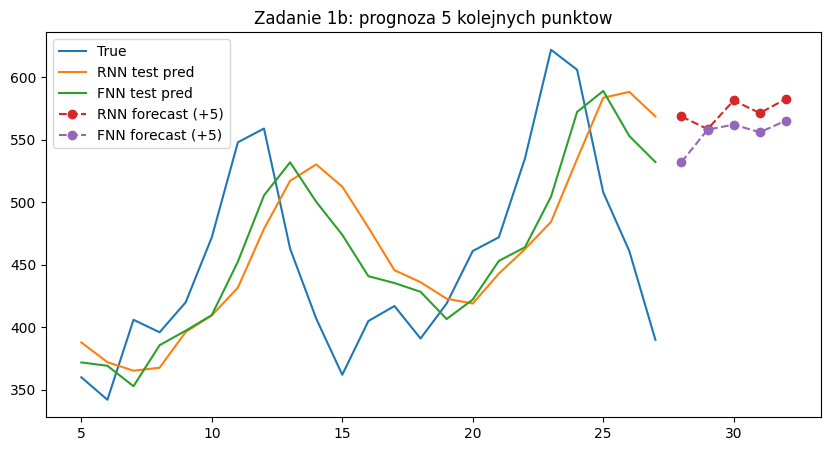

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 185.0071 - val_loss: 215.4480
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 56.3137 - val_loss: 106.5742
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 45.3782 - val_loss: 83.9987
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 37.8581 - val_loss: 80.5565
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 37.1046 - val_loss: 78.3690
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 36.2948 - val_loss: 77.9538
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 35.6301 - val_loss: 77.4544
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 34.6682 - val_loss: 76.1703
Epoch 9/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 34.6085 - val_loss: 75.8330
Epoch 10/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 34.3545 - val_loss: 75.8507
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
RNN many-to-many -> MSE: 7825.92, MAE: 73.45
RNN many-to-one  -> MSE: 7111.75, MAE: 70.62


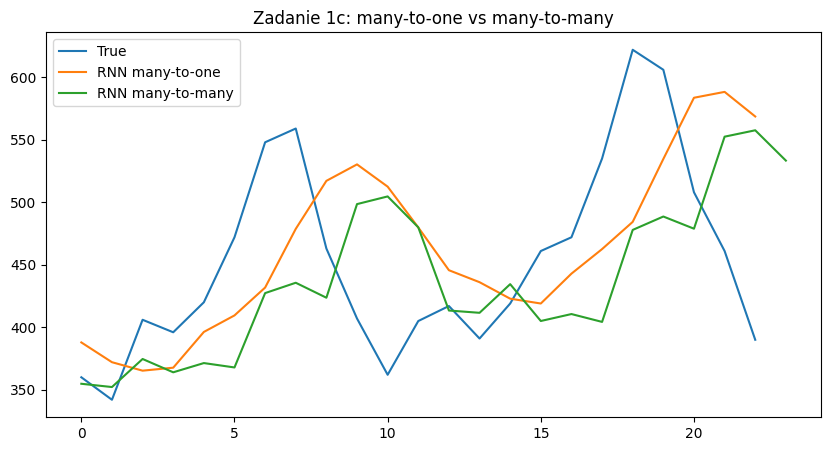

In [20]:
# === Zadanie 1a: MSE i MAE dla FNN i RNN ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse_fnn = mean_squared_error(y_test, y_pred_fnn)
mae_fnn = mean_absolute_error(y_test, y_pred_fnn)
mse_rnn = mean_squared_error(y_test, y_pred_rnn)
mae_rnn = mean_absolute_error(y_test, y_pred_rnn)

print(f"FNN -> MSE: {mse_fnn:.2f}, MAE: {mae_fnn:.2f}")
print(f"RNN -> MSE: {mse_rnn:.2f}, MAE: {mae_rnn:.2f}")

# === Zadanie 1b: iteracyjna prognoza 5 kolejnych punktow (recursive forecasting) ===
n_future = 5

# punkt startowy: ostatnia sekwencja ze zbioru testowego
seq_rnn = X_test[-1].copy().reshape(seq_length, 1)
seq_fnn = X_test[-1].copy().flatten()

future_rnn, future_fnn = [], []
for _ in range(n_future):
    p_rnn = rnn_model.predict(seq_rnn.reshape(1, seq_length, 1), verbose=0)[0, 0]
    p_fnn = fnn_model.predict(seq_fnn.reshape(1, seq_length), verbose=0)[0, 0]
    future_rnn.append(p_rnn)
    future_fnn.append(p_fnn)
    # przesuniecie okna i dolozenie predykcji na koniec
    seq_rnn = np.append(seq_rnn[1:], [[p_rnn]], axis=0)
    seq_fnn = np.append(seq_fnn[1:], p_fnn)

# Wykres: dane testowe + prognoza 5 punktow do przodu
start = seq_length
x_test_range = range(start, start + len(y_test))
x_future_range = range(start + len(y_test), start + len(y_test) + n_future)

plt.figure(figsize=(10, 5))
plt.plot(x_test_range, y_test, label="True")
plt.plot(x_test_range, y_pred_rnn, label="RNN test pred")
plt.plot(x_test_range, y_pred_fnn, label="FNN test pred")
plt.plot(x_future_range, future_rnn, "o--", label="RNN forecast (+5)")
plt.plot(x_future_range, future_fnn, "o--", label="FNN forecast (+5)")
plt.legend()
plt.title("Zadanie 1b: prognoza 5 kolejnych punktow")
plt.show()

# === Zadanie 1c: RNN many-to-many (5 -> 3) ===
output_length = 3

def create_data_m2m(data, seq_length=5, output_length=3):
    X, y = [], []
    for i in range(len(data) - seq_length - output_length + 1):
        X.append(data[i:i + seq_length, 0])
        y.append(data[i + seq_length:i + seq_length + output_length, 0])
    return np.array(X), np.array(y)

X_train_m2m, y_train_m2m = create_data_m2m(train, seq_length, output_length)
X_test_m2m, y_test_m2m = create_data_m2m(test, seq_length, output_length)
X_train_m2m = X_train_m2m.reshape(X_train_m2m.shape[0], seq_length, 1)
X_test_m2m = X_test_m2m.reshape(X_test_m2m.shape[0], seq_length, 1)

rnn_m2m = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(seq_length, 1)),
    Dense(output_length)
])
rnn_m2m.compile(optimizer='adam', loss='mae')
rnn_m2m.fit(X_train_m2m, y_train_m2m, epochs=10, batch_size=8,
            validation_data=(X_test_m2m, y_test_m2m), verbose=1)

y_pred_m2m = rnn_m2m.predict(X_test_m2m)

# Strategia: aktualizacja co 3 predykcje (sklejamy okna bez nakladki)
pred_m2m_flat = y_pred_m2m[::output_length].flatten()
true_m2m_flat = y_test_m2m[::output_length].flatten()
min_len = min(len(pred_m2m_flat), len(true_m2m_flat))
pred_m2m_flat = pred_m2m_flat[:min_len]
true_m2m_flat = true_m2m_flat[:min_len]

mse_m2m = mean_squared_error(true_m2m_flat, pred_m2m_flat)
mae_m2m = mean_absolute_error(true_m2m_flat, pred_m2m_flat)
print(f"RNN many-to-many -> MSE: {mse_m2m:.2f}, MAE: {mae_m2m:.2f}")
print(f"RNN many-to-one  -> MSE: {mse_rnn:.2f}, MAE: {mae_rnn:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(range(len(y_test)), y_test, label="True")
plt.plot(range(len(y_pred_rnn)), y_pred_rnn, label="RNN many-to-one")
plt.plot(range(len(pred_m2m_flat)), pred_m2m_flat, label="RNN many-to-many")
plt.legend()
plt.title("Zadanie 1c: many-to-one vs many-to-many")
plt.show()


## Zadanie 2 – Implementacja prostego 'neuronu RNN' (perceptron z pamięcią)

Rekurencyjne sieci neuronowe (**RNN**) są przeznaczone do modelowania **danych sekwencyjnych**, takich jak szeregi czasowe, tekst czy sygnały audio. W przeciwieństwie do klasycznych sieci neuronowych, RNN posiadają **stan pamięci (hidden state)**, który pozwala przekazywać informację pomiędzy kolejnymi krokami czasowymi. Dzięki temu model może uwzględniać kontekst wcześniejszych obserwacji podczas przetwarzania bieżących danych.

W nowoczesnych architekturach stosuje się często komórki **LSTM** lub **GRU**, które posiadają złożony mechanizm bramek sterujących przepływem informacji. Jednak implementacja takich komórek od podstaw jest stosunkowo skomplikowana.  

Dlatego w tym zadaniu zaimplementujemy **najprostszą możliwą komórkę RNN**, którą można interpretować jako **perceptron z pamięcią**. Komórka ta wykorzystuje zarówno bieżące dane wejściowe, jak i aktywację z poprzedniego kroku czasowego.

Dla jednego kroku czasowego $t$ predykcja komórki może być zapisana jako:

$$
y_{pred} = w \cdot x + w_m \cdot a_m + b
$$

gdzie:

- $x$ – aktualne dane wejściowe  
- $a_m$ – aktywacja neuronu z poprzedniego kroku czasowego (stan pamięci)  
- $w$ – wagi dla danych wejściowych  
- $w_m$ – wagi dla części pamięciowej  
- $b$ – bias  

---

### Zadanie

Zaimplementować pojedynczą komórkę RNN wykonującą **propagację w przód (forward pass)**.

1. Zainicjalizować wagi dla danych wejściowych `w`
2. Zainicjalizować bias `b`
3. Zainicjalizować wagi części pamięciowej `w_m`
4. Zdefiniować aktywację z poprzedniego kroku czasowego `a_m`
5. Zdefiniować przykładowe dane wejściowe `x_train` oraz wartości docelowe `y_train`
6. Obliczyć predykcję modelu:
$$
y_{pred} = w \cdot x_train + w_m \cdot a_m + b
$$



7. Obliczyć wartość funkcji straty **MSE (Mean Squared Error)** między predykcją z komórki RNN a przykładowymi danymi wejściowymi.



---

### Źródła

Hochreiter, S., Schmidhuber, J. (1997). *Long Short-Term Memory.* Neural Computation, 9(8), 1735–1780.

Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press – Chapter 10: Sequence Modeling. https://www.deeplearningbook.org

Backpropagation Through Time – wprowadzenie: https://www.geeksforgeeks.org/ml-back-propagation-through-time/


In [21]:
# === Zadanie 2: prosty neuron RNN -- forward pass ===
# y_pred = w * x + w_m * a_m + b

np.random.seed(0)

# 1) wagi dla wejscia
w = np.random.randn()
# 2) bias
b = np.random.randn()
# 3) wagi czesci pamieciowej
w_m = np.random.randn()
# 4) aktywacja z poprzedniego kroku (stan pamieci)
a_m = 0.0

# 5) przykladowe dane wejsciowe i targety (sekwencja) - lokalne nazwy zeby nie nadpisac globalnych X_train/y_train
x_seq = np.array([0.5, 0.8, 1.2, 0.3, 0.9])
y_seq = np.array([0.6, 0.9, 1.0, 0.5, 0.8])

# 6) propagacja w przod krok po kroku -- a_m przenosi sie z kroku t-1
preds = []
a_m = 0.0
for x_t in x_seq:
    y_pred = w * x_t + w_m * a_m + b
    preds.append(y_pred)
    a_m = y_pred   # aktywacja z biezacego kroku staje sie pamiecia dla nastepnego

preds = np.array(preds)

# 7) MSE
mse = np.mean((preds - y_seq) ** 2)

print("Wagi: w =", w, " w_m =", w_m, " b =", b)
print("Predykcje:", preds)
print("Targety:  ", y_seq)
print(f"MSE = {mse:.4f}")


Wagi: w = 1.764052345967664  w_m = 0.9787379841057392  b = 0.4001572083672233
Predykcje: [1.28218338 3.06632066 5.51814453 6.33019056 8.18340227]
Targety:   [0.6 0.9 1.  0.5 0.8]
MSE = 22.8155


## LSTM

**LSTM (Long Short-Term Memory)** to specjalny typ komórki stosowanej w rekurencyjnych sieciach neuronowych (RNN), zaprojektowany w celu rozwiązania problemu **zanikającego i eksplodującego gradientu** (*vanishing/exploding gradient problem*), który często występuje podczas uczenia klasycznych sieci RNN metodą propagacji wstecznej w czasie (*Backpropagation Through Time, BPTT*).

W standardowej komórce RNN stan ukryty jest wielokrotnie przekształcany przez funkcje nieliniowe, co powoduje, że gradienty propagowane przez wiele kroków czasowych mogą bardzo szybko maleć lub rosnąć. W rezultacie model ma trudność z uczeniem **długoterminowych zależności w sekwencjach danych**.

### Problem Backpropagation Through Time w klasycznych RNN

W klasycznej sieci RNN stan ukryty jest obliczany rekurencyjnie:

$$
h_t = \phi(W_h h_{t-1} + W_x x_t + b)
$$

Podczas uczenia stosuje się **Backpropagation Through Time (BPTT)**, czyli propagację gradientu przez wszystkie kroki czasowe. Zgodnie z regułą łańcuchową gradient względem wcześniejszych stanów ma postać iloczynu wielu pochodnych:

$$
\frac{\partial L}{\partial h_t}
=
\frac{\partial L}{\partial h_T}
\prod_{k=t}^{T-1}
\frac{\partial h_{k+1}}{\partial h_k}
$$

Każdy czynnik zawiera macierz wag rekurencyjnych oraz pochodną funkcji aktywacji. W efekcie gradient jest wielokrotnie mnożony przez wartości zwykle **mniejsze lub większe od 1**.

#### Vanishing gradient

Jeżeli wartości te są mniejsze od 1 (np. pochodne `tanh` lub `sigmoid`), gradient **zanika wykładniczo** wraz z liczbą kroków czasowych. Wtedy:

- gradient dla odległych kroków jest bliski zeru  
- parametry odpowiedzialne za długoterminowe zależności prawie się nie uczą  
- model wykorzystuje głównie **krótki kontekst sekwencji**

#### Exploding gradient

Jeżeli wartości są większe od 1, gradient może **rosnąć wykładniczo**, co prowadzi do niestabilności uczenia i bardzo dużych aktualizacji wag.

W praktyce oznacza to, że klasyczne RNN mają trudność z uczeniem **długoterminowych zależności w danych sekwencyjnych**, co było jedną z głównych motywacji do wprowadzenia architektur takich jak LSTM i GRU.

Komórka **LSTM** wprowadza dodatkową strukturę pamięci zwaną **stanem komórki (cell state)** oraz mechanizm **bramek sterujących przepływem informacji**.

### Struktura komórki LSTM

Komórka LSTM zawiera trzy główne bramki sterujące przepływem informacji:

1. **Bramka zapominania (forget gate)**  
   Decyduje, które informacje z poprzedniego stanu komórki powinny zostać zachowane, a które usunięte.

2. **Bramka wejścia (input gate)**  
   Określa, które nowe informacje z bieżącego wejścia zostaną zapisane w stanie komórki.

3. **Bramka wyjścia (output gate)**  
   Kontroluje, jaka część stanu komórki zostanie przekazana do stanu ukrytego i wykorzystana jako wyjście komórki.

Dzięki tej strukturze stan komórki może **przenosić informacje przez wiele kroków czasowych z minimalną degradacją gradientu**, co umożliwia efektywne uczenie zależności długoterminowych.

### Zalety LSTM w porównaniu do klasycznego RNN

- **Pamięć długoterminowa**  
  Architektura LSTM umożliwia przechowywanie informacji przez długi czas dzięki oddzielnemu stanowi komórki.

- **Kontrola przepływu informacji**  
  Mechanizm bramek pozwala modelowi decydować, które informacje należy zachować, zaktualizować lub usunąć.

- **Lepsze modelowanie zależności czasowych**  
  W przeciwieństwie do klasycznych RNN, które dobrze modelują jedynie krótkie zależności, LSTM potrafią uczyć się relacji w sekwencjach o dużym horyzoncie czasowym.


---

### Źródła

Hochreiter, S., & Schmidhuber, J. (1997). **Long Short-Term Memory.** *Neural Computation*, 9(8), 1735–1780. https://doi.org/10.1162/neco.1997.9.8.1735

Goodfellow, I., Bengio, Y., & Courville, A. (2016). **Deep Learning.** MIT Press – Chapter 10: Sequence Modeling. https://www.deeplearningbook.org


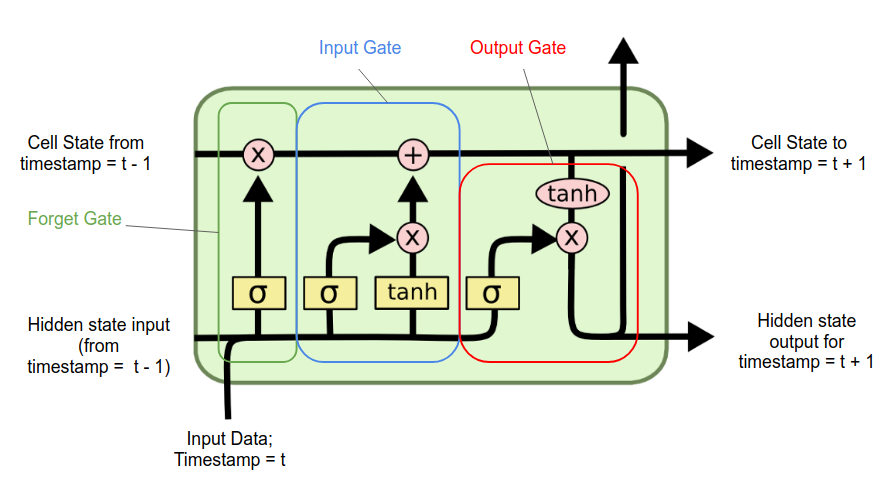

(źródło: https://medium.com/analytics-vidhya/lstms-explained-a-complete-technically-accurate-conceptual-guide-with-keras-2a650327e8f2)

## Zadanie 3 – Prognozowanie szeregu czasowego z użyciem LSTM

Celem zadania jest zbudowanie modelu prognozowania szeregu czasowego dla zbioru **AirPassengers** z wykorzystaniem komórki **LSTM**.

Model LSTM należy wytrenować w sposób analogiczny do modelu **RNN**, który został zbudowany w poprzednim zadaniu. W najprostszym wariancie można uzyskać taki model poprzez:

- zastąpienie warstwy `SimpleRNN` warstwą `LSTM`
- ewentualne dostosowanie liczby neuronów lub liczby warstw w architekturze sieci

Dokumentacja warstwy:
https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

---

### Kroki do wykonania

1. Zbudować model sieci neuronowej wykorzystujący warstwę **LSTM**.
2. Wytrenować model na tym samym zbiorze treningowym co model **SimpleRNN**.
3. Wykonać predykcję dla danych testowych.
4. Obliczyć metryki jakości predykcji:
   - **MSE (Mean Squared Error)**
   - **MAE (Mean Absolute Error)**
5. Porównać wyniki z modelem wykorzystującym **SimpleRNN**.

---

### Analiza wyników

Porównanie modeli powinno obejmować:

- wartości metryk **MSE** i **MAE** na zbiorze testowym
- **wizualizację predykcji** obu modeli na wspólnym wykresie wraz z rzeczywistymi wartościami szeregu czasowego

Pozwoli to ocenić, czy zastosowanie komórki **LSTM**, która lepiej modeluje zależności długoterminowe, prowadzi do poprawy jakości prognozy.

---

**NOTE**

Aby porównanie modeli było rzetelne, należy zastosować **identyczne przetwarzanie danych** jak w przypadku modelu SimpleRNN, w szczególności:

- ten sam sposób **skalowania danych**
- tę samą długość sekwencji wejściowej (*sequence length*)
- ten sam podział na **zbiór treningowy i testowy**

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 151.9620 - val_loss: 102.9703
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 33.4379 - val_loss: 67.6191
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 28.8666 - val_loss: 56.5457
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 24.9894 - val_loss: 47.0121
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 25.7847 - val_loss: 63.2862
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 26.7425 - val_loss: 69.8529
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 35.3161 - val_loss: 63.8295
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 29.9920 - val_loss: 70.3917
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 29.9308 - val_loss: 65.9884
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 26.8467 - val_loss: 64.9056
Epoch 11/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 30.9109 - val_loss: 78.4301
Epoch 12/150
14/14 ━━━━━━━━━

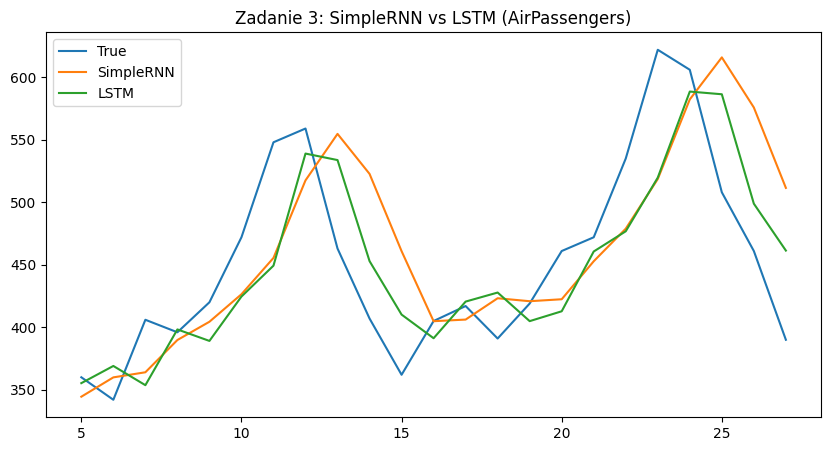

In [122]:
# === Zadanie 3: LSTM dla AirPassengers ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

lstm_model = Sequential([
    LSTM(300, activation='relu', return_sequences=False, input_shape=(seq_length, 1)),
    Dense(1),
])
lstm_model.compile(optimizer='adamW', loss='mae')
lstm_model.fit(X_train, y_train, epochs=150, batch_size=8,
               validation_data=(X_test, y_test), verbose=1)

y_pred_lstm = lstm_model.predict(X_test).flatten()

mse_lstm = mean_squared_error(y_test, y_pred_lstm)
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
mse_rnn_ = mean_squared_error(y_test, y_pred_rnn)
mae_rnn_ = mean_absolute_error(y_test, y_pred_rnn)

print(f"SimpleRNN -> MSE: {mse_rnn_:.2f}, MAE: {mae_rnn_:.2f}")
print(f"LSTM      -> MSE: {mse_lstm:.2f}, MAE: {mae_lstm:.2f}")

# wykres porownawczy
plt.figure(figsize=(10, 5))
plt.plot(range(seq_length, seq_length + len(y_test)), y_test, label="True")
plt.plot(range(seq_length, seq_length + len(y_pred_rnn)), y_pred_rnn, label="SimpleRNN")
plt.plot(range(seq_length, seq_length + len(y_pred_lstm)), y_pred_lstm, label="LSTM")
plt.legend()
plt.title("Zadanie 3: SimpleRNN vs LSTM (AirPassengers)")
plt.show()


## Zadanie 4 – Agregacja szeregu czasowego (EXTRA)

Dane w szeregach czasowych mogą być analizowane na różnych poziomach **agregacji czasowej** (np. dzień, miesiąc, kwartał, rok). Zmiana poziomu agregacji wpływa na:

- liczbę dostępnych obserwacji,
- poziom szumu w danych,
- widoczność trendów i sezonowości,
- sposób przygotowania danych dla modeli uczenia maszynowego.

Agregacja może również wpływać na **proces trenowania modeli sieci neuronowych**, ponieważ zmienia się długość szeregu oraz charakter zależności czasowych.

W zbiorze **AirPassengers** dane są zapisane w **agregacji miesięcznej**. W tym zadaniu należy przekształcić je do **agregacji rocznej**.

---

### Zadanie

1. Wykonać **roczną agregację** danych ze zbioru **AirPassengers**.
2. Wartości w każdym roku powinny zostać **uśrednione**.
3. Zwizualizować otrzymany zagregowany szereg czasowy na wykresie.

---

### Wskazówki

Do wykonania agregacji można wykorzystać funkcje biblioteki **pandas**.

W szczególności:

- w razie potrzeby przekonwertować kolumnę z datą na typ `datetime` przy użyciu funkcji `to_datetime`
- ustawić kolumnę dat jako **indeks czasowy**
- użyć metody `resample`, aby zmienić częstotliwość szeregu czasowego

Dokumentacja:

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html

Podczas agregacji można użyć parametru:

- `rule='Y'` lub `rule='YE'` – agregacja roczna

---

**TIP**

Po agregacji liczba punktów danych będzie znacznie mniejsza niż w przypadku danych miesięcznych. Warto zwrócić uwagę, jak wpływa to na **kształt szeregu czasowego** oraz widoczność trendu w danych.

            Passengers
Month                 
1949-12-31  126.666667
1950-12-31  139.666667
1951-12-31  170.166667
1952-12-31  197.000000
1953-12-31  225.000000
1954-12-31  238.916667
1955-12-31  284.000000
1956-12-31  328.250000
1957-12-31  368.416667
1958-12-31  381.000000
1959-12-31  428.333333
1960-12-31  476.166667


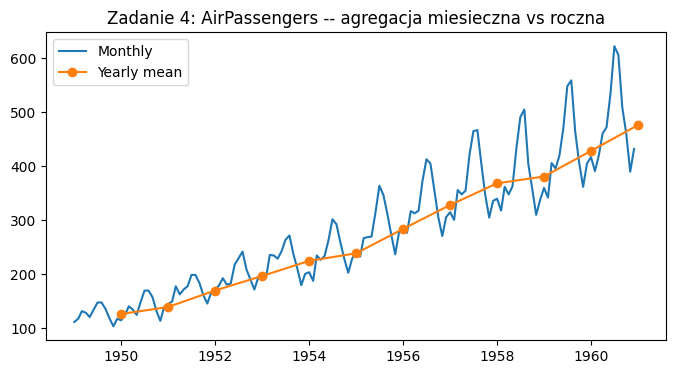

In [23]:
# === Zadanie 4: roczna agregacja AirPassengers ===
data_air = pd.read_csv(
    "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv",
    parse_dates=["Month"], index_col="Month"
)
data_air = data_air.dropna()

# rule='YE' -- year-end
data_yearly = data_air.resample('YE').mean()
print(data_yearly)

plt.figure(figsize=(8, 4))
plt.plot(data_air.index, data_air["Passengers"], label="Monthly")
plt.plot(data_yearly.index, data_yearly["Passengers"], "o-", label="Yearly mean")
plt.legend()
plt.title("Zadanie 4: AirPassengers -- agregacja miesieczna vs roczna")
plt.show()


## Zadanie 5 – Modelowanie szeregu czasowego COVID-19 z użyciem RNN

Celem zadania jest zbudowanie modeli prognozujących liczbę **potwierdzonych przypadków COVID-19** na podstawie danych historycznych. Dane mają charakter **szeregu czasowego**, dlatego zastosowane zostaną modele rekurencyjne (**RNN / LSTM**), które potrafią wykorzystywać zależności pomiędzy kolejnymi obserwacjami w czasie.

W zadaniu porównane zostaną dwa typy architektur:

- **SimpleRNN** – podstawowa komórka rekurencyjna
- **LSTM** – bardziej zaawansowana komórka umożliwiająca modelowanie długoterminowych zależności

W obu przypadkach wykorzystany zostanie model **many-to-one**, w którym kilka kolejnych obserwacji szeregu czasowego stanowi wejście modelu, a wyjściem jest **jedna prognozowana wartość**.

Do oceny jakości predykcji należy wykorzystać metryki:

- **MAE (Mean Absolute Error)**
- **MSE (Mean Squared Error)**

---

## 5.1. Model SimpleRNN – dane dzienne

Wytrenować model prognozowania liczby przypadków COVID-19 z wykorzystaniem warstwy **`SimpleRNN`**.

**Założenia:**

- dane wejściowe: **agregacja dzienna**
- dane nie powinny być dodatkowo modyfikowane (poza standardowym przygotowaniem do modelu)

**Kroki:**

1. Zbudować i wytrenować model **many-to-one** z warstwą `SimpleRNN`.
2. Obliczyć metryki **MAE** oraz **MSE** na zbiorze testowym.
3. Zwizualizować:
   - rzeczywiste wartości szeregu czasowego
   - predykcje modelu na danych testowych.

---

## 5.2. Model LSTM – dane dzienne

Powtórzyć eksperyment z wykorzystaniem modelu **LSTM**.

**Kroki:**

1. Zbudować model **many-to-one** z warstwą `LSTM`.
2. Wytrenować model na tych samych danych treningowych.
3. Obliczyć metryki **MAE** oraz **MSE** na zbiorze testowym.
4. Zwizualizować:
   - rzeczywiste wartości danych testowych
   - predykcje modelu.

---

## 5.3. Porównanie modeli

Porównać modele:

- **SimpleRNN (many-to-one)**
- **LSTM (many-to-one)**

Porównanie powinno obejmować:

- wartości metryk **MAE** i **MSE** na zbiorze testowym
- wizualne porównanie **predykcji na wykresie**

Na tej podstawie należy ocenić, czy zastosowanie komórki **LSTM** poprawia jakość prognozy.


In [124]:
# Load dataset
data_covid = pd.read_csv("https://raw.githubusercontent.com/datasets/covid-19/main/data/time-series-19-covid-combined.csv")
data_covid['Date'] = pd.to_datetime(data_covid['Date'])
data_covid = data_covid.groupby('Date')['Confirmed'].sum().reset_index()
data_covid.index = data_covid.Date
data_covid.drop("Date", axis=1, inplace=True)

In [125]:
data_covid.head()

,Confirmed
Date,
2020-01-22,557
2020-01-23,657
2020-01-24,944
2020-01-25,1437
2020-01-26,2120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3228351.5000 - val_loss: 1957355.7500
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 626416.9375 - val_loss: 1838753.5000
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 723654.5625 - val_loss: 7084550.0000
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1908696.5000 - val_loss: 14699754.0000
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1325406.8750 - val_loss: 7619698.5000
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1641774.5000 - val_loss: 4326302.0000
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 680463.7500 - val_loss: 1254407.5000
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 645711.0625 - val_loss: 2565344.0000
Epoch 9/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 975032.0000 - val_loss: 1259655.1250
Epoch 10/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 686044.4375 - val_loss: 6180887.5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Epo

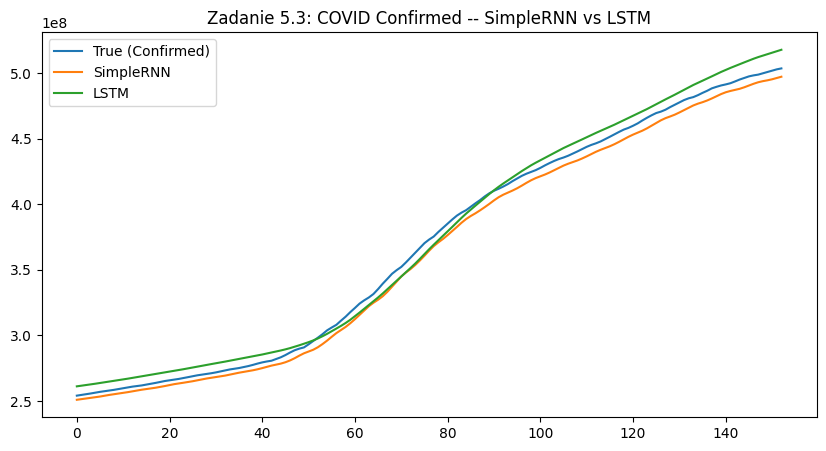

In [128]:
# === Zadanie 5.1 + 5.2 + 5.3: SimpleRNN vs LSTM dla COVID (Confirmed, dzienne) ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

covid_values = data_covid["Confirmed"].values.reshape(-1, 1).astype("float32")

train_size_c = int(covid_values.shape[0] * 0.8)
train_c, test_c = covid_values[:train_size_c], covid_values[train_size_c:]

seq_length_c = 10
X_train_c, y_train_c = create_data(train_c, seq_length=seq_length_c)
X_test_c, y_test_c = create_data(test_c, seq_length=seq_length_c)
X_train_c = X_train_c.reshape(X_train_c.shape[0], seq_length_c, 1)
X_test_c = X_test_c.reshape(X_test_c.shape[0], seq_length_c, 1)

# --- 5.1 SimpleRNN ---
rnn_covid = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(seq_length_c, 1)),
    Dense(1)
])
rnn_covid.compile(optimizer='adam', loss='mae')
rnn_covid.fit(X_train_c, y_train_c, epochs=10, batch_size=16,
              validation_data=(X_test_c, y_test_c), verbose=1)
y_pred_rnn_c = rnn_covid.predict(X_test_c).flatten()

# --- 5.2 LSTM ---
lstm_covid = Sequential([
    LSTM(200, activation='relu', input_shape=(seq_length_c, 1)),
    Dense(1)
])
lstm_covid.compile(optimizer='adam', loss='mae')
lstm_covid.fit(X_train_c, y_train_c, epochs=60, batch_size=16,
               validation_data=(X_test_c, y_test_c), verbose=1)
y_pred_lstm_c = lstm_covid.predict(X_test_c).flatten()

# --- 5.3 metryki + wykres ---
print(f"SimpleRNN -> MSE: {mean_squared_error(y_test_c, y_pred_rnn_c):.2e}, "
      f"MAE: {mean_absolute_error(y_test_c, y_pred_rnn_c):.2e}")
print(f"LSTM      -> MSE: {mean_squared_error(y_test_c, y_pred_lstm_c):.2e}, "
      f"MAE: {mean_absolute_error(y_test_c, y_pred_lstm_c):.2e}")

plt.figure(figsize=(10, 5))
plt.plot(y_test_c, label="True (Confirmed)")
plt.plot(y_pred_rnn_c, label="SimpleRNN")
plt.plot(y_pred_lstm_c, label="LSTM")
plt.legend()
plt.title("Zadanie 5.3: COVID Confirmed -- SimpleRNN vs LSTM")
plt.show()


---

## Zadanie 5.4. Model LSTM – dane z agregacją tygodniową (EXTRA)

W ostatnim kroku należy sprawdzić, jak **zmiana poziomu agregacji danych** wpływa na działanie modelu.

**Kroki:**

1. Utworzyć nowy zbiór danych z **agregacją tygodniową**:
   - agregacja może być wykonana poprzez **średnią** lub **medianę**.
2. Przygotować dane do modelowania:
   - przeskalować dane (jeśli było stosowane wcześniej)
   - wybrać odpowiednią długość sekwencji wejściowej (**`seq_length`**).
3. Wytrenować model **LSTM many-to-one** na danych tygodniowych.
4. Obliczyć metryki **MAE** i **MSE** dla zbioru testowego.
5. Wykonać **prognozę dla 5 kolejnych punktów czasowych** po danych testowych.
6. Zwizualizować:
   - dane rzeczywiste
   - predykcje modelu
   - prognozę przyszłych wartości.

Epoch 1/120


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.1405 - val_loss: 0.4961
Epoch 2/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0854 - val_loss: 0.2160
Epoch 3/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0431 - val_loss: 0.0607
Epoch 4/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0148 - val_loss: 0.0594
Epoch 5/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - val_loss: 0.0331
Epoch 6/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0112 - val_loss: 0.0371
Epoch 7/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0074 - val_loss: 0.0395
Epoch 8/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0078 - val_loss: 0.0377
Epoch 9/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0081 - val_loss: 0.0559
Epoch 10/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0094 - val_loss: 0.0346
Epoch 11/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0063 - val_loss: 0.0654
Epoch 12/120
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0

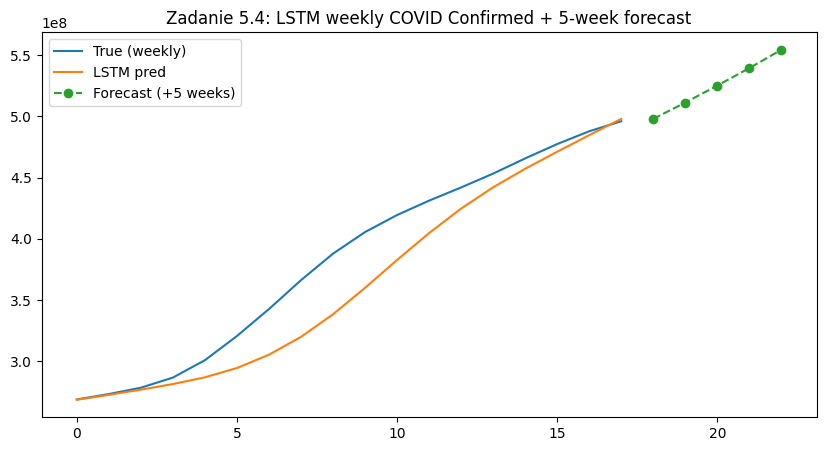

In [135]:
# === Zadanie 5.4: LSTM dla COVID Confirmed -- agregacja tygodniowa ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

# tygodniowa srednia (W = week-end Sunday)
data_covid_weekly = data_covid["Confirmed"].resample("W").mean()
weekly = data_covid_weekly.values.reshape(-1, 1).astype("float32")

# skalowanie pomaga przy duzych wartosciach -- inverse_transform na koncu
scaler_w = MinMaxScaler()
weekly_scaled = scaler_w.fit_transform(weekly)

train_size_w = int(weekly_scaled.shape[0] * 0.8)
train_w, test_w = weekly_scaled[:train_size_w], weekly_scaled[train_size_w:]

seq_length_w = 5
X_train_w, y_train_w = create_data(train_w, seq_length=seq_length_w)
X_test_w, y_test_w = create_data(test_w, seq_length=seq_length_w)
X_train_w = X_train_w.reshape(X_train_w.shape[0], seq_length_w, 1)
X_test_w = X_test_w.reshape(X_test_w.shape[0], seq_length_w, 1)

lstm_weekly = Sequential([
    LSTM(150, activation='relu', input_shape=(seq_length_w, 1)),
    Dense(1)
])
lstm_weekly.compile(optimizer='adam', loss='mae')
lstm_weekly.fit(X_train_w, y_train_w, epochs=120, batch_size=8,
                validation_data=(X_test_w, y_test_w), verbose=1)

y_pred_w_scaled = lstm_weekly.predict(X_test_w).flatten()
# odwrocenie skalowania
y_pred_w = scaler_w.inverse_transform(y_pred_w_scaled.reshape(-1, 1)).flatten()
y_test_w_orig = scaler_w.inverse_transform(y_test_w.reshape(-1, 1)).flatten()

print(f"LSTM (weekly) -> MSE: {mean_squared_error(y_test_w_orig, y_pred_w):.2e}, "
      f"MAE: {mean_absolute_error(y_test_w_orig, y_pred_w):.2e}")

# prognoza 5 kolejnych tygodni (recursive)
n_future = 5
seq_w = X_test_w[-1].copy().reshape(seq_length_w, 1)
future_w_scaled = []
for _ in range(n_future):
    p = lstm_weekly.predict(seq_w.reshape(1, seq_length_w, 1), verbose=0)[0, 0]
    future_w_scaled.append(p)
    seq_w = np.append(seq_w[1:], [[p]], axis=0)
future_w = scaler_w.inverse_transform(np.array(future_w_scaled).reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 5))
x_test_range = range(len(y_test_w_orig))
x_future_range = range(len(y_test_w_orig), len(y_test_w_orig) + n_future)
plt.plot(x_test_range, y_test_w_orig, label="True (weekly)")
plt.plot(x_test_range, y_pred_w, label="LSTM pred")
plt.plot(x_future_range, future_w, "o--", label="Forecast (+5 weeks)")
plt.legend()
plt.title("Zadanie 5.4: LSTM weekly COVID Confirmed + 5-week forecast")
plt.show()


## Zadanie 6 – Wpływ skalowania zmiennej wyjściowej na jakość modelu

Celem zadania jest sprawdzenie, czy **skalowanie danych wyjściowych (targetu)** wpływa na skuteczność modeli **RNN** i **LSTM** dla zbioru danych COVID-19.

**Kroki do wykonania:**

1. Zastosować skalowanie zmiennej wyjściowej `Confirmed` dla zbioru danych Covid przy użyciu **`MinMaxScaler`** z biblioteki `scikit-learn`.
2. Wytrenować modele:
   - **SimpleRNN (many-to-one)**
   - **LSTM (many-to-one)**
3. Wykonać predykcje dla danych testowych.
4. Odwrócić skalowanie predykcji przy użyciu metody `inverse_transform`, aby porównać je z oryginalnymi wartościami.
5. Porównać metryki **MAE** i **MSE** z wynikami modeli wytrenowanych ze skalowaniem targetu i bez skalowania.

**NOTE:** Skalowanie targetu może poprawić stabilność i skuteczność uczenia sieci neuronowej, ale **wszystkie predykcje muszą być przekształcone z powrotem** do oryginalnej skali przed interpretacją wyników.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
=== Z SKALOWANIEM TARGETU (po inverse_transform) ===
SimpleRNN -> MSE: 2.84e+14, MAE: 1.46e+07
LSTM      -> MSE: 3.54e+14, MAE: 1.53e+07

=== BEZ SKALOWANIA TARGETU (Zadanie 5) ===
SimpleRNN -> MSE: 3.73e+12, MAE: 1.74e+06
LSTM      -> MSE: 1.44e+17, MAE: 3.70e+08


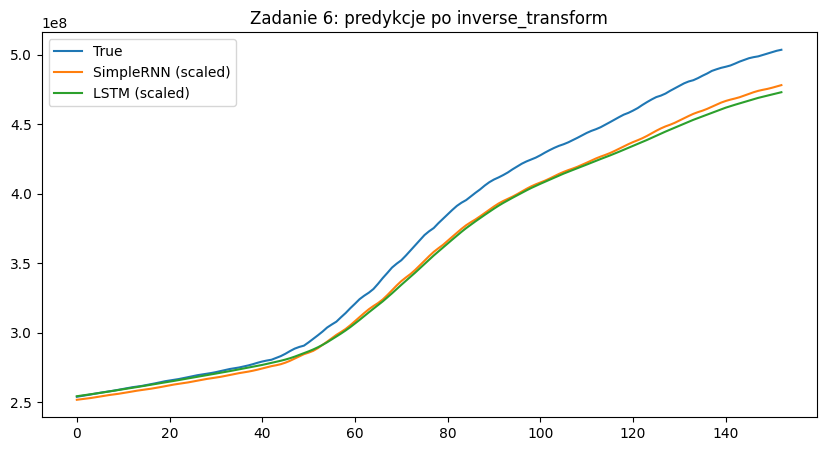

In [28]:
# === Zadanie 6: wplyw skalowania zmiennej wyjsciowej (Confirmed) ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

covid_raw = data_covid["Confirmed"].values.reshape(-1, 1).astype("float32")

scaler_t = MinMaxScaler()
covid_scaled = scaler_t.fit_transform(covid_raw)

train_size_s = int(covid_scaled.shape[0] * 0.8)
train_s, test_s = covid_scaled[:train_size_s], covid_scaled[train_size_s:]

seq_length_s = 10
X_train_s, y_train_s = create_data(train_s, seq_length=seq_length_s)
X_test_s, y_test_s = create_data(test_s, seq_length=seq_length_s)
X_train_s = X_train_s.reshape(X_train_s.shape[0], seq_length_s, 1)
X_test_s = X_test_s.reshape(X_test_s.shape[0], seq_length_s, 1)

# RNN ze skalowaniem
rnn_s = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(seq_length_s, 1)),
    Dense(1)
])
rnn_s.compile(optimizer='adam', loss='mae')
rnn_s.fit(X_train_s, y_train_s, epochs=10, batch_size=16,
          validation_data=(X_test_s, y_test_s), verbose=0)

# LSTM ze skalowaniem
lstm_s = Sequential([
    LSTM(50, activation='tanh', input_shape=(seq_length_s, 1)),
    Dense(1)
])
lstm_s.compile(optimizer='adam', loss='mae')
lstm_s.fit(X_train_s, y_train_s, epochs=10, batch_size=16,
           validation_data=(X_test_s, y_test_s), verbose=0)

# predykcje + odwrocenie skalowania
y_pred_rnn_s = scaler_t.inverse_transform(rnn_s.predict(X_test_s)).flatten()
y_pred_lstm_s = scaler_t.inverse_transform(lstm_s.predict(X_test_s)).flatten()
y_test_orig = scaler_t.inverse_transform(y_test_s.reshape(-1, 1)).flatten()

print("=== Z SKALOWANIEM TARGETU (po inverse_transform) ===")
print(f"SimpleRNN -> MSE: {mean_squared_error(y_test_orig, y_pred_rnn_s):.2e}, "
      f"MAE: {mean_absolute_error(y_test_orig, y_pred_rnn_s):.2e}")
print(f"LSTM      -> MSE: {mean_squared_error(y_test_orig, y_pred_lstm_s):.2e}, "
      f"MAE: {mean_absolute_error(y_test_orig, y_pred_lstm_s):.2e}")

# porownanie z wynikami bez skalowania (z Zadania 5)
try:
    print("\n=== BEZ SKALOWANIA TARGETU (Zadanie 5) ===")
    print(f"SimpleRNN -> MSE: {mean_squared_error(y_test_c, y_pred_rnn_c):.2e}, "
          f"MAE: {mean_absolute_error(y_test_c, y_pred_rnn_c):.2e}")
    print(f"LSTM      -> MSE: {mean_squared_error(y_test_c, y_pred_lstm_c):.2e}, "
          f"MAE: {mean_absolute_error(y_test_c, y_pred_lstm_c):.2e}")
except NameError:
    print("(Najpierw uruchom Zadanie 5, zeby porownac.)")

plt.figure(figsize=(10, 5))
plt.plot(y_test_orig, label="True")
plt.plot(y_pred_rnn_s, label="SimpleRNN (scaled)")
plt.plot(y_pred_lstm_s, label="LSTM (scaled)")
plt.legend()
plt.title("Zadanie 6: predykcje po inverse_transform")
plt.show()



---

## Zadanie 7 – Modelowanie liczby zgonów w COVID-19

W tym zadaniu wykonamy analogiczną analizę jak w **Zadaniu 5**, ale dla zmiennej `Deaths`.

**Kroki do wykonania:**

1. Przygotować dane dzienne dotyczące liczby zgonów (`Deaths`).
2. Zbudować i wytrenować modele:
   - **SimpleRNN (many-to-one)**
   - **LSTM (many-to-one)**
3. Obliczyć metryki **MAE** i **MSE** dla danych testowych.
4. Wykonać prognozę dla 5 przyszłych punktów czasowych i zwizualizować je na wykresie.

---

In [137]:
# Load dataset
data_covid = pd.read_csv("https://raw.githubusercontent.com/datasets/covid-19/main/data/time-series-19-covid-combined.csv")
data_covid['Date'] = pd.to_datetime(data_covid['Date'])
data_covid = data_covid.groupby('Date')['Deaths'].sum().reset_index()
data_covid.index = data_covid.Date
data_covid.drop("Date", axis=1, inplace=True)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1655617.7500 - val_loss: 774612.5625
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 123489.2500 - val_loss: 103754.4453
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31952.8984 - val_loss: 18596.7578
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 25038.4453 - val_loss: 95397.1250
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 36690.9805 - val_loss: 68252.2188
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 21462.2578 - val_loss: 64514.4844
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28136.0938 - val_loss: 280687.5625
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 50097.8125 - val_loss: 47376.6289
Epoch 9/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29329.2520 - val_loss: 154492.4375
Epoch 10/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20699.3008 - val_loss: 26924.6992
Epoch 11/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19616.8125 - val_loss

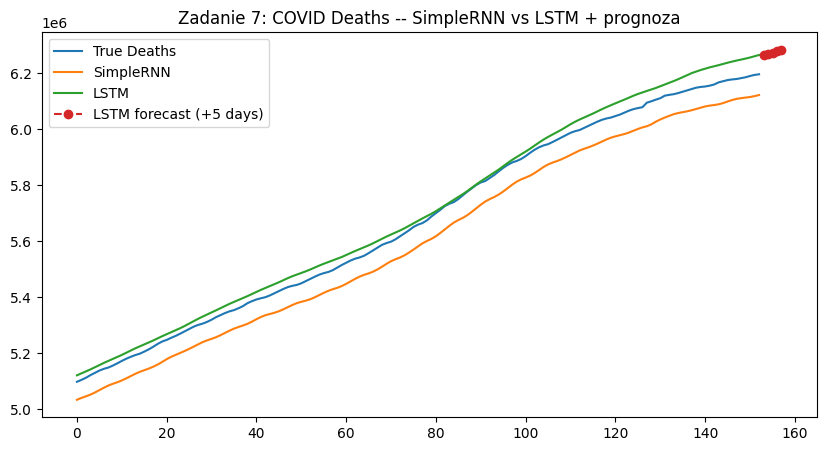

In [142]:
# === Zadanie 7: SimpleRNN i LSTM dla COVID Deaths (dzienne) ===
from sklearn.metrics import mean_squared_error, mean_absolute_error

deaths = data_covid["Deaths"].values.reshape(-1, 1).astype("float32")

train_size_d = int(deaths.shape[0] * 0.8)
train_d, test_d = deaths[:train_size_d], deaths[train_size_d:]

seq_length_d = 10
X_train_d, y_train_d = create_data(train_d, seq_length=seq_length_d)
X_test_d, y_test_d = create_data(test_d, seq_length=seq_length_d)
X_train_d = X_train_d.reshape(X_train_d.shape[0], seq_length_d, 1)
X_test_d = X_test_d.reshape(X_test_d.shape[0], seq_length_d, 1)

rnn_d = Sequential([
    SimpleRNN(80, activation='relu', input_shape=(seq_length_d, 1)),
    Dense(1)
])
rnn_d.compile(optimizer='adam', loss='mae')
rnn_d.fit(X_train_d, y_train_d, epochs=50, batch_size=16,
          validation_data=(X_test_d, y_test_d), verbose=1)
y_pred_rnn_d = rnn_d.predict(X_test_d).flatten()

lstm_d = Sequential([
    LSTM(100, activation='relu', input_shape=(seq_length_d, 1)),
    Dense(1)
])
lstm_d.compile(optimizer='adam', loss='mae')
lstm_d.fit(X_train_d, y_train_d, epochs=60, batch_size=16,
           validation_data=(X_test_d, y_test_d), verbose=1)
y_pred_lstm_d = lstm_d.predict(X_test_d).flatten()

print(f"SimpleRNN (Deaths) -> MSE: {mean_squared_error(y_test_d, y_pred_rnn_d):.2e}, "
      f"MAE: {mean_absolute_error(y_test_d, y_pred_rnn_d):.2e}")
print(f"LSTM (Deaths)      -> MSE: {mean_squared_error(y_test_d, y_pred_lstm_d):.2e}, "
      f"MAE: {mean_absolute_error(y_test_d, y_pred_lstm_d):.2e}")

# prognoza 5 kolejnych dni (LSTM)
n_future = 5
seq_d = X_test_d[-1].copy().reshape(seq_length_d, 1)
future_d = []
for _ in range(n_future):
    p = lstm_d.predict(seq_d.reshape(1, seq_length_d, 1), verbose=0)[0, 0]
    future_d.append(p)
    seq_d = np.append(seq_d[1:], [[p]], axis=0)

plt.figure(figsize=(10, 5))
x_test_range = range(len(y_test_d))
x_future_range = range(len(y_test_d), len(y_test_d) + n_future)
plt.plot(x_test_range, y_test_d, label="True Deaths")
plt.plot(x_test_range, y_pred_rnn_d, label="SimpleRNN")
plt.plot(x_test_range, y_pred_lstm_d, label="LSTM")
plt.plot(x_future_range, future_d, "o--", label="LSTM forecast (+5 days)")
plt.legend()
plt.title("Zadanie 7: COVID Deaths -- SimpleRNN vs LSTM + prognoza")
plt.show()
